In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [18]:
# Import necessary libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load the dataset (make sure you've added the dataset to your Kaggle notebook)
data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# Select features and target
features = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
target = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")

# Example: Predict the price for a custom house (optional)
example = pd.DataFrame([[1800, 3, 2]], columns=['GrLivArea', 'BedroomAbvGr', 'FullBath'])
predicted_price = model.predict(example)
print(f"Predicted price for 1800 sqft, 3 bed, 2 bath: ${predicted_price[0]:,.2f}")


Mean Squared Error: 2806426667.25
Predicted price for 1800 sqft, 3 bed, 2 bath: $219,572.25


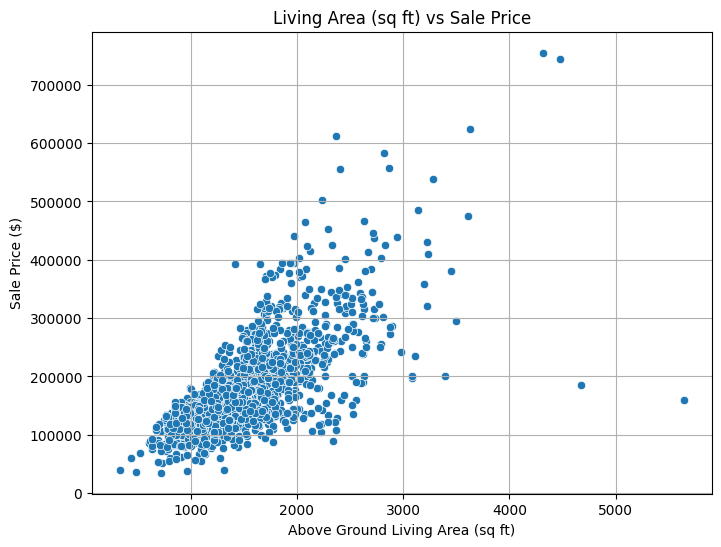

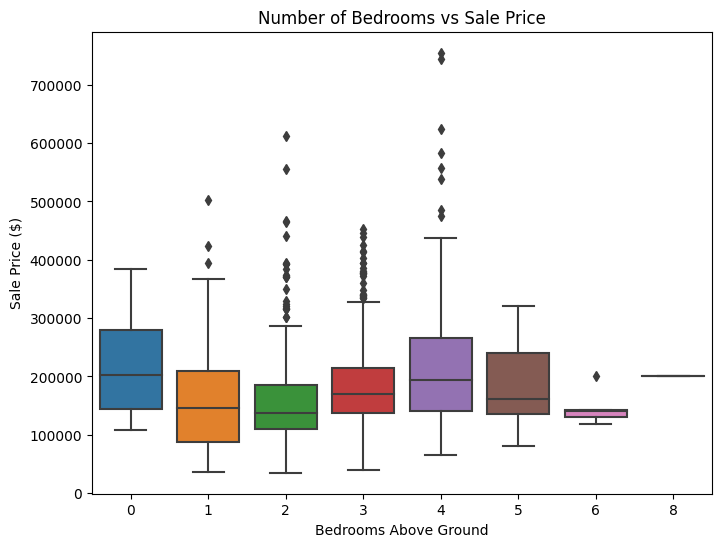

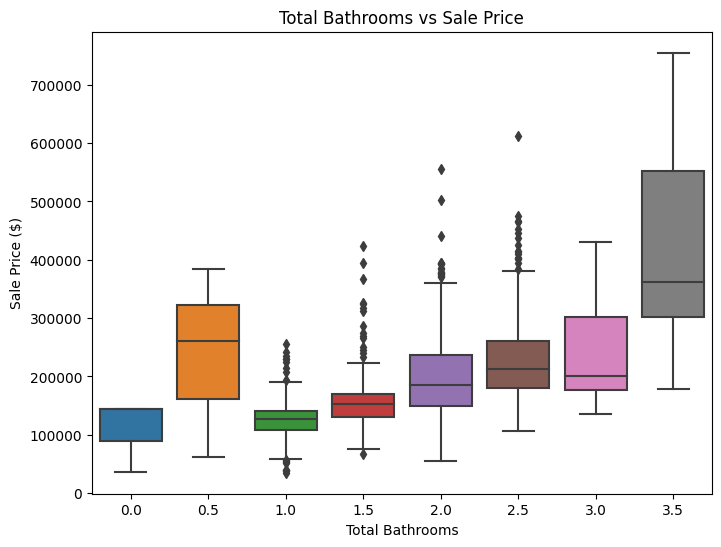

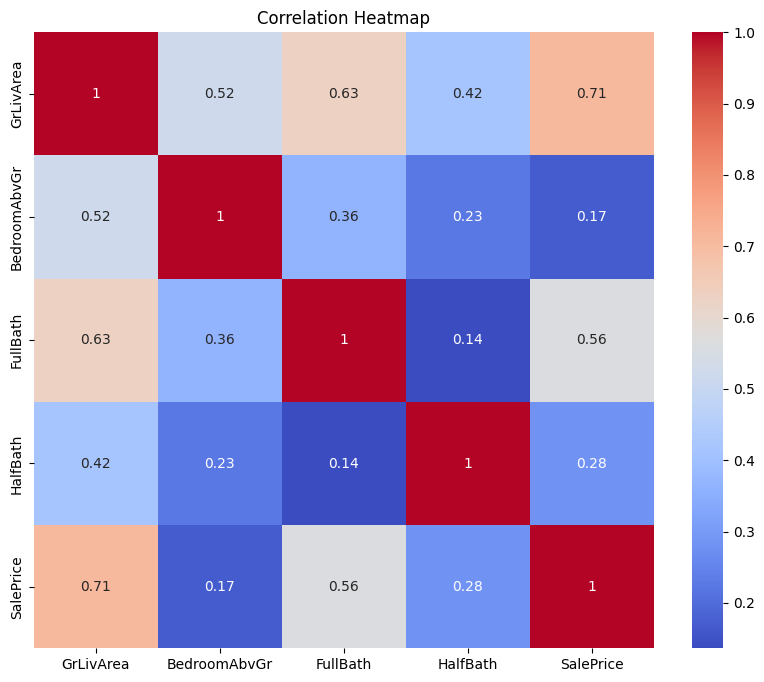

In [19]:
import pandas as pd

# Load training dataset
df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# Show the first few rows
df.head()

import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting
%matplotlib inline

plt.figure(figsize=(8, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Living Area (sq ft) vs Sale Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='BedroomAbvGr', y='SalePrice', data=df)
plt.title('Number of Bedrooms vs Sale Price')
plt.xlabel('Bedrooms Above Ground')
plt.ylabel('Sale Price ($)')
plt.show()

# Create a new column combining full and half baths
df['TotalBathrooms'] = df['FullBath'] + 0.5 * df['HalfBath']

plt.figure(figsize=(8, 6))
sns.boxplot(x='TotalBathrooms', y='SalePrice', data=df)
plt.title('Total Bathrooms vs Sale Price')
plt.xlabel('Total Bathrooms')
plt.ylabel('Sale Price ($)')
plt.show()

plt.figure(figsize=(10, 8))
corr = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'SalePrice']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
